# Dimensionality Reduction of Cacao Flower Microbiome Data

PCA and t-SNE on 16S (bacteria) and ITS1 (fungi) feature tables,  
coloured by sample metadata and microscopy phenotypes.

**Preprocessing:** CLR transformation (Aitchison geometry) — the standard approach for compositional microbiome count data.

## 0. Imports & paths

In [1]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.transforms as transforms
import seaborn as sns

# Read feature tables in BIOM format exported from R
import biom
# Aitchison log-ratio transformation applied to relative abundance data prior to dimensionality reduction
from skbio.stats.composition import clr 
# Linear dimensionality reduction (PCA) projects data onto orthogonal axes of maximum variance
from sklearn.decomposition import PCA
# Add confidence ellipses for PCA plots
from matplotlib.patches import Ellipse

# Non-linear dimensionality reduction (t-SNE) projects data onto a lower-dimensional space while preserving local structure
from sklearn.manifold import TSNE
# Add convex hulls for t-SNE plots
from scipy.spatial import ConvexHull
# Non-linear dimensionality reduction (UMAP) projects data onto a lower-dimensional space while preserving local structure
from umap import UMAP

ROOT     = Path('..').resolve()
BIOM_DIR = ROOT / 'results' / 'biom'
DATA_DIR = ROOT / 'data'
FIG_DIR  = ROOT / 'results' / 'figures' / 'dim_reduction'
FIG_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
print('Paths OK')

Paths OK


## 1. Load data

In [2]:
# Feature tables — biosamples only (controls already removed in R)
# Origninal QIIME2 (DADA2) output was processed in R with decontam() packacge to remove contaminants more prevalent in negative controls
# Also, taxonomy filtration was applied to remove ASVs that were unassigned at the kingdom level or assigned to chloroplasts or mitochondria (for 16S)
tbl_16s  = biom.load_table(str(BIOM_DIR / 'cfm_16s_bacteria_biosamples_feature-table.biom'))
tbl_its1 = biom.load_table(str(BIOM_DIR / 'cfm_its1_fungi_biosamples_feature-table.biom'))

# rows = ASVs, columns = samples
counts_16s  = tbl_16s.to_dataframe(dense=True)
counts_its1 = tbl_its1.to_dataframe(dense=True)

print(f'16S  : {counts_16s.shape[1]} samples, {counts_16s.shape[0]} ASVs')
print(f'ITS1 : {counts_its1.shape[1]} samples, {counts_its1.shape[0]} ASVs')

16S  : 294 samples, 25035 ASVs
ITS1 : 294 samples, 11929 ASVs


In [3]:
# Metadata (tab-separated, QIIME2 format; skip the q2:types row)
meta_raw = pd.read_csv(
    DATA_DIR / 'sample_metadata_with_microscopy.txt',
    sep='\t', index_col=0, dtype=str
)
meta = meta_raw.drop(index='#q2:types', errors='ignore').copy()

# Fix decimal separator (comma → dot) and cast numeric columns
num_cols = [
    'dna_conc_hs_16s', 'dna_conc_hs_its1',
    'pi_dic', 'pi_clsm', 'callose_plug_index', 'fungal_colonization_score'
]
for col in num_cols:
    if col in meta.columns:
        meta[col] = (
            meta[col].str.replace(',', '.', regex=False)
                     .pipe(pd.to_numeric, errors='coerce')
        )

# Binary columns (stored as '0'/'1' strings)
bin_cols = [
    'is_specimen', 'specimen_qc_pass',
    'is_pollination_dic', 'is_pollination_clsm',
    'is_germination', 'is_hyphae_present', 'is_spore_present',
    'is_insect_present'
]
for col in bin_cols:
    if col in meta.columns:
        meta[col] = pd.to_numeric(meta[col], errors='coerce').astype('Int64')

print(meta.shape)
meta.head(3)

(337, 33)


,sublibrary_id,sample_type,management_type,farmer,farm_id,tree_id,collection_batch,extraction_batch,pcr_batch_16s,fwd_primer_16s,...,pi_dic,is_pollination_clsm,pi_clsm,is_germination,callose_plug_index,is_hyphae_present,is_spore_present,fungal_colonization_score,is_insect_present,Unnamed: 33
sample-id,,,,,,,,,,,,,,,,,,,,,
cib11,C1_14C_13_12,bagged_flower,inside_forest,issac_boadu,ib,ib1,2023-12-15,2024-10-01,2024-10-14,515fA,...,0.0,1,11.0,0,0.0,1,0,1.0,0,NaN
cib12,D1_14B_13_12,bagged_flower,inside_forest,issac_boadu,ib,ib1,2023-12-15,2024-10-01,2024-10-14,515fA,...,NaN,<NA>,NaN,<NA>,NaN,<NA>,<NA>,NaN,0,NaN
cib13,E1_13E_13_12,bagged_flower,inside_forest,issac_boadu,ib,ib1,2023-12-15,2024-10-01,2024-10-14,515fA,...,NaN,<NA>,NaN,<NA>,NaN,<NA>,<NA>,NaN,0,NaN


## 2. CLR transformation — helper functions

Define `multiplicative_replacement` and `prepare_clr`.
Filtering comes next; CLR is computed on filtered counts afterwards.

In [4]:
def multiplicative_replacement(mat: np.ndarray, delta: float | None = None) -> np.ndarray:
    """
    Replace zeros in a (samples x features) compositional matrix with delta for numerical stability.
    Delta is a small value (default: 1/n^2, where n is the number of features) hat ensures the replaced 
    values are small enough to not distort the data significantly.

    mat: 2D array of shape (samples, features)
    delta: Optional small value to replace zeros (if None, defaults to 1/n^2)
    returns: 2D array of the same shape with zeros replaced by delta
    """
    mat = np.asarray(mat, dtype=float)
    n = mat.shape[1]
    if delta is None:
        delta = 1.0 / n ** 2
    result = mat.copy()
    for i in range(len(result)):
        zm = result[i] == 0
        k  = zm.sum()
        if k:
            result[i,  zm] = delta
            result[i, ~zm] *= 1.0 - k * delta
    return result


def prepare_clr(counts_df: pd.DataFrame) -> pd.DataFrame:
    """
    counts_df : ASVs x samples  (raw counts)
    returns   : CLR matrix as DataFrame  samples x ASVs
    """
    # Total Sum Scaling → relative abundance
    ra   = counts_df.div(counts_df.sum(axis=0), axis=1)  # ASVs x samples
    ra_T = ra.T.values                                    # samples x ASVs
    comp = multiplicative_replacement(ra_T)
    return pd.DataFrame(
        clr(comp),
        index=counts_df.columns,
        columns=counts_df.index
    )


## 3. Prevalence & abundance filtering

Remove rare ASVs **before** computing CLR, so the geometric mean
is not skewed by singleton noise.

Three thresholds are compared via scree plots; the chosen threshold
is applied and `counts_16s_f` / `counts_its1_f` are produced.

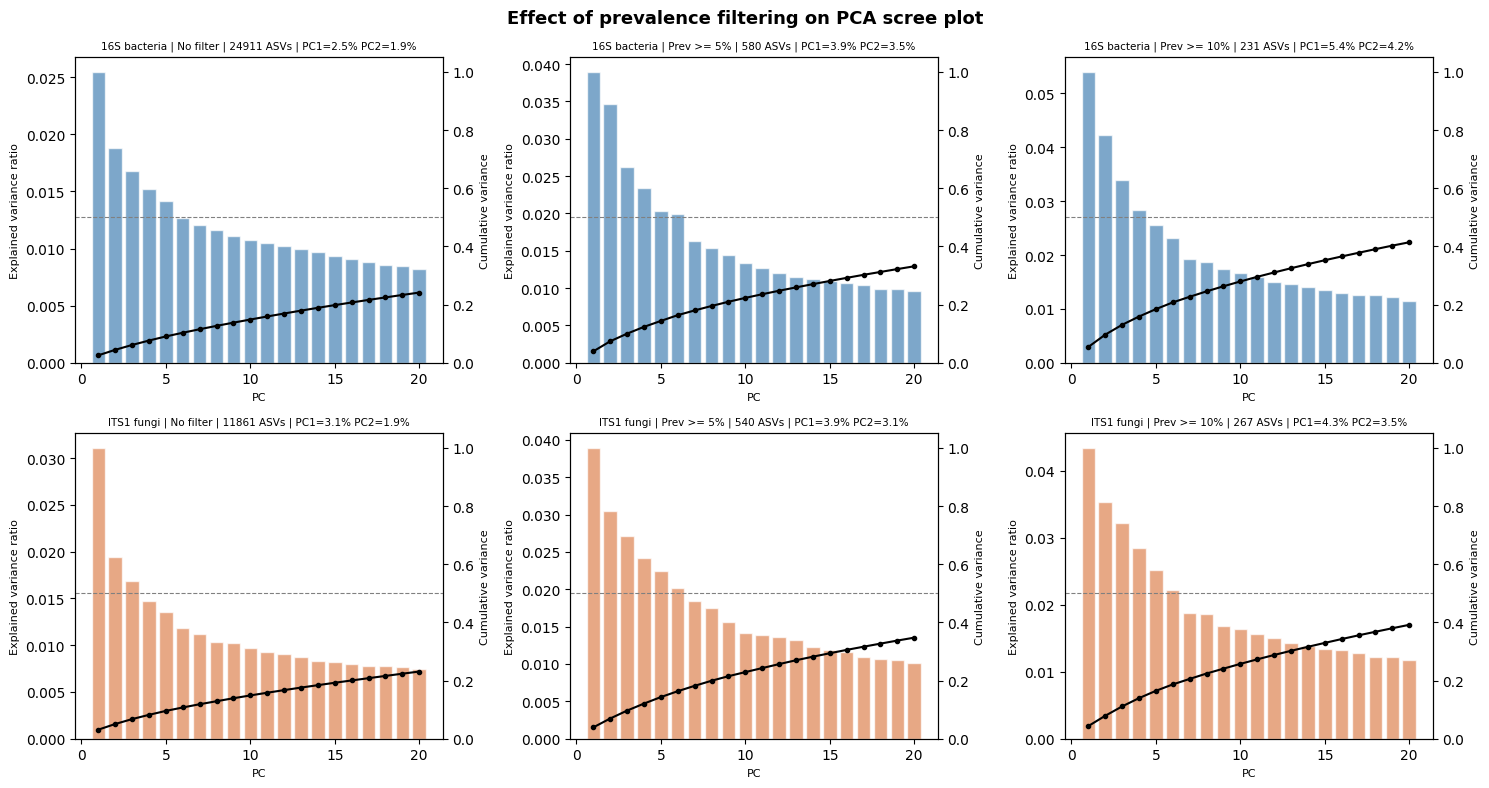

16S  after filter: 226 ASVs  (was 25035 )
ITS1 after filter: 265 ASVs (was 11929 )
16S   sparsity: 99.1% → 79.0%  (prev ≥ 10%, min_total ≥ 500)
ITS1  sparsity: 98.6% → 73.9%  (prev ≥ 10%, min_total ≥ 500)


In [5]:
def filter_counts(counts_df, min_prevalence=0.0, min_total=10):
    n_samples  = counts_df.shape[1]
    prevalence = (counts_df > 0).sum(axis=1) / n_samples
    total      = counts_df.sum(axis=1)
    keep       = (prevalence >= min_prevalence) & (total >= min_total)
    return counts_df[keep]

thresholds = [
    ('No filter',   0.0,  1),
    ('Prev >= 5%',  0.05, 10),
    ('Prev >= 10%', 0.10, 10),
]

fig, axes = plt.subplots(2, len(thresholds), figsize=(5 * len(thresholds), 8))
fig.suptitle('Effect of prevalence filtering on PCA scree plot',
             fontsize=13, fontweight='bold')

for col_idx, (label, min_prev, min_tot) in enumerate(thresholds):
    for row_idx, (counts_raw, title_pfx, color) in enumerate([
        (counts_16s,  '16S bacteria', 'steelblue'),
        (counts_its1, 'ITS1 fungi',   '#DD8452'),
    ]):
        counts_f = filter_counts(counts_raw, min_prev, min_tot)
        clr_f    = prepare_clr(counts_f)
        n_asv    = counts_f.shape[0]
        n_samp   = counts_f.shape[1]
        pca_f    = PCA(n_components=min(n_samp - 1, 20), random_state=RANDOM_STATE)
        pca_f.fit(clr_f.values)
        ev_f     = pca_f.explained_variance_ratio_
        cumul_f  = np.cumsum(ev_f)

        ax  = axes[row_idx, col_idx]
        ax2 = ax.twinx()
        ax.bar(range(1, len(ev_f) + 1), ev_f, color=color, alpha=0.7, edgecolor='white')
        ax2.plot(range(1, len(ev_f) + 1), cumul_f, color='black',
                 marker='o', markersize=3, lw=1.5)
        ax2.axhline(0.5, color='grey', ls='--', lw=0.8)
        ax2.set_ylim(0, 1.05)
        ax2.set_ylabel('Cumulative variance', fontsize=8)
        ax.set_xlabel('PC', fontsize=8)
        ax.set_ylabel('Explained variance ratio', fontsize=8)
        pc1_str  = '{:.1%}'.format(ev_f[0])
        pc2_str  = '{:.1%}'.format(ev_f[1])
        ax.set_title(
            title_pfx + ' | ' + label + ' | '
            + str(n_asv) + ' ASVs | PC1=' + pc1_str + ' PC2=' + pc2_str,
            fontsize=7.5
        )

plt.tight_layout()
fig.savefig(FIG_DIR / 'filtering_scree_comparison.pdf', bbox_inches='tight')
plt.show()

# Pick threshold — change if needed
PREV_THRESHOLD = 0.10
MIN_TOTAL      = 500
counts_16s_f   = filter_counts(counts_16s,  PREV_THRESHOLD, MIN_TOTAL)
counts_its1_f  = filter_counts(counts_its1, PREV_THRESHOLD, MIN_TOTAL)
print('16S  after filter:', counts_16s_f.shape[0], 'ASVs  (was', counts_16s.shape[0], ')')
print('ITS1 after filter:', counts_its1_f.shape[0], 'ASVs (was', counts_its1.shape[0], ')')

for lbl, raw, filt in [('16S ', counts_16s, counts_16s_f), ('ITS1', counts_its1, counts_its1_f)]:
    sp_before = (raw  == 0).values.mean()
    sp_after  = (filt == 0).values.mean()
    print(f'{lbl}  sparsity: {sp_before:.1%} → {sp_after:.1%}  '
          f'(prev ≥ {PREV_THRESHOLD:.0%}, min_total ≥ {MIN_TOTAL})')


## 4. CLR transformation — compute on filtered counts

Now that noisy ASVs are removed, `prepare_clr` is applied to
`counts_16s_f` / `counts_its1_f`. The geometric mean is stable.

In [6]:
# CLR on prevalence-filtered counts
clr_16s  = prepare_clr(counts_16s_f)
clr_its1 = prepare_clr(counts_its1_f)

print(f'CLR 16S  : {clr_16s.shape}   (samples x ASVs)')
print(f'CLR ITS1 : {clr_its1.shape}  (samples x ASVs)')


CLR 16S  : (294, 226)   (samples x ASVs)
CLR ITS1 : (294, 265)  (samples x ASVs)


## 5. Colour palettes and visual helpers

In [7]:
# ── Confidence ellipse (2-sigma) ──────────────────────────
def confidence_ellipse(x, y, ax, n_std=2.0, **kwargs):
    if len(x) < 3:
        return
    cov     = np.cov(x, y)
    pearson = cov[0, 1] / np.sqrt(cov[0, 0] * cov[1, 1] + 1e-12)
    ellipse = Ellipse(
        (0, 0),
        width=np.sqrt(1 + pearson) * 2,
        height=np.sqrt(1 - pearson) * 2,
        **kwargs,
    )
    t = (
        transforms.Affine2D()
        .rotate_deg(45)
        .scale(np.sqrt(cov[0, 0]) * n_std, np.sqrt(cov[1, 1]) * n_std)
        .translate(np.mean(x), np.mean(y))
    )
    ellipse.set_transform(t + ax.transData)
    ax.add_patch(ellipse)


# ── Convex hull ───────────────────────────────────────────
def draw_convex_hull(pts, ax, color):
    """
    Draw the convex hull of a set of 2D points.

    Convex hull = the smallest convex polygon that contains all points.
    Algorithm: scipy QuickHull, O(n log n).
    hull.vertices gives the indices of boundary points in counter-clockwise
    order; we close the polygon by appending the first vertex at the end.

    Appropriate for t-SNE and UMAP: both methods place similar samples
    close together, so the hull shows the spatial extent of each group.
    This is NOT a confidence region (unlike an ellipse) — it simply
    outlines the observed range of the group in the 2D embedding.
    """
    if len(pts) < 3:
        return
    try:
        hull = ConvexHull(pts)
        hp   = pts[hull.vertices]
        hp   = np.vstack([hp, hp[0]])  # close the polygon
        ax.plot(hp[:, 0], hp[:, 1], color=color, lw=1.2, alpha=0.7)
        ax.fill(hp[:, 0], hp[:, 1], color=color, alpha=0.07)
    except Exception:
        pass


# ── Helper for consistent label conversion ───────────────────────────────────
def safe_to_str(x):
    if pd.isna(x):
        return "NaN"
    try:
        # Пытаемся превратить 1.0 в "1", но текст оставляем текстом
        return str(int(float(x)))
    except (ValueError, TypeError):
        return str(x)

# ── Categorical colour palettes ───────────────────────────────────────────────
PALETTES = {
    'sample_type': {
        'bagged_flower'  : '#4C72B0',
        'unbagged_flower': '#DD8452',
    },
    'tree_id': dict(zip(
        sorted(meta['tree_id'].dropna().unique()),
        sns.color_palette('tab10', n_colors=meta['tree_id'].nunique())
    )),
    'management_type': dict(zip(
        sorted(meta['management_type'].dropna().unique()),
        sns.color_palette('Set1', n_colors=meta['management_type'].nunique())
    )),
    'farm_id': dict(zip(
        sorted(meta['farm_id'].dropna().unique()),
        sns.color_palette('Dark2', n_colors=meta['farm_id'].nunique())
    )),
    'farmer': dict(zip(
        sorted(meta['farmer'].dropna().unique()),
        sns.color_palette('tab10', n_colors=meta['farmer'].nunique())
    )),
    'collection_batch': dict(zip(
        sorted(meta['collection_batch'].dropna().unique()),
        sns.color_palette('Paired', n_colors=meta['collection_batch'].nunique())
    )),
    'extraction_batch': dict(zip(
        sorted(meta['extraction_batch'].dropna().unique()),
        sns.color_palette('Set3', n_colors=meta['extraction_batch'].nunique())
    )),
    'pcr_batch_16s': dict(zip(
        sorted(meta['pcr_batch_16s'].dropna().unique()),
        sns.color_palette('Set2', n_colors=meta['pcr_batch_16s'].nunique())
    )),
    'pcr_batch_its1': dict(zip(
        sorted(meta['pcr_batch_its1'].dropna().unique()),
        sns.color_palette('Set2', n_colors=meta['pcr_batch_its1'].nunique())
    )),
    'qubit_batch_16s': dict(zip(
        sorted(meta['qubit_batch_16s'].dropna().unique()),
        sns.color_palette('Set2', n_colors=meta['qubit_batch_16s'].nunique())
    )),
    'qubit_batch_its1': dict(zip(
        sorted(meta['qubit_batch_its1'].dropna().unique()),
        sns.color_palette('Set2', n_colors=meta['qubit_batch_its1'].nunique())
    )),
    'is_pollination_dic': {
        0: '#4393C3',
        1: '#D6604D',
        pd.NA: '#BBBBBB',
    },
    'is_pollination_clsm': {
        0: '#4393C3',
        1: '#D6604D',
        pd.NA: '#BBBBBB',
    },
    'is_germination': {
        0: '#4393C3',
        1: '#D6604D',
        pd.NA: '#BBBBBB',
    },
    'is_hyphae_present': {
        0: '#4393C3',
        1: '#D6604D',
        pd.NA: '#BBBBBB',
    },
    'fungal_colonization_score': {
        0  : '#F7F7F7',
        1  : '#FEE08B',
        2  : '#FDAE61',
        3  : '#F46D43',
        4  : '#D73027',
        5  : '#B30000',
        pd.NA: '#BBBBBB',
    },
    'is_spore_present': {
        0: '#4393C3',
        1: '#D6604D',
        pd.NA: '#BBBBBB',
    },
    'is_insect_present': {
        0: '#4393C3',
        1: '#D6604D',
        pd.NA: '#BBBBBB',
    },
}

# ── Continuous colormaps ──────────────────────────────────────────────────────
CMAPS = {
    'pi_dic'             : 'YlOrRd',
    'pi_clsm'            : 'YlOrRd',
    'callose_plug_index' : 'PuBu',
}

print('Palettes defined.')


Palettes defined.


## 6. PCA helper functions

In [8]:
def plot_pca_panel(
    pcs, ev, meta_aligned, color_vars, palettes,
    title_prefix='', n_cols=3, figsize_per=5, ellipses=True
):
    """
    Grid of PCA scatter plots, one panel per metadata variable.
    Draws 2-sigma confidence ellipses and centroid crosses (same style as HW6).
    """
    n_plots = len(color_vars)
    n_rows  = (n_plots + n_cols - 1) // n_cols
    fig, axes = plt.subplots(
        n_rows, n_cols,
        figsize=(figsize_per * n_cols, figsize_per * n_rows)
    )
    axes = np.array(axes).flatten()
    fig.suptitle(f'PCA — {title_prefix}', fontsize=14, fontweight='bold', y=1.01)

    for ax_idx, col in enumerate(color_vars):
        ax      = axes[ax_idx]
        palette = palettes.get(col, {})
        series  = meta_aligned[col] if col in meta_aligned.columns else pd.Series(
            [pd.NA] * len(pcs), name=col
        )

        if not palette:
            uniq    = list(series.dropna().unique())
            palette = dict(zip(uniq, sns.color_palette('tab10', n_colors=len(uniq))))

        for val, color in palette.items():
            mask = series.isna().to_numpy(dtype=bool) if pd.isna(val) else (series == val).to_numpy(dtype=bool, na_value=False)
            if not mask.any():
                continue
            ax.scatter(
                pcs[mask, 0], pcs[mask, 1],
                c=[color], label=str(val),
                alpha=0.6, s=50, linewidths=0.4, edgecolors='black'
            )
            if ellipses and not pd.isna(val) and mask.sum() >= 3:
                confidence_ellipse(
                    pcs[mask, 0], pcs[mask, 1], ax,
                    n_std=2.0, facecolor='none',
                    edgecolor=color, linewidth=1.5, alpha=0.8
                )
                ax.plot(
                    pcs[mask, 0].mean(), pcs[mask, 1].mean(),
                    marker='x', color=color, markersize=8, markeredgewidth=2
                )

        ax.set_xlabel(f'PC1 ({ev[0]:.1%})', fontsize=9)
        ax.set_ylabel(f'PC2 ({ev[1]:.1%})', fontsize=9)
        ax.set_title(col, fontsize=10)
        ax.legend(fontsize=8, markerscale=1.5, framealpha=0.6, loc='best')

    for ax in axes[n_plots:]:
        ax.set_visible(False)

    plt.tight_layout()
    return fig


def plot_pca_continuous(pcs, ev, meta_aligned, cont_vars, cmaps, title_prefix=''):
    """
    PCA scatter coloured by continuous variables.
    Samples with NA are shown in grey so they are not silently dropped
    (matplotlib skips NaN values in c= arrays without warning).
    """
    n    = len(cont_vars)
    fig, axes = plt.subplots(1, n, figsize=(5 * n, 4.5))
    if n == 1:
        axes = [axes]
    fig.suptitle(f'PCA — {title_prefix} (continuous variables)',
                 fontsize=13, fontweight='bold')

    for ax, col in zip(axes, cont_vars):
        values = pd.to_numeric(
            meta_aligned.get(col, pd.Series(np.nan, index=meta_aligned.index)),
            errors='coerce'
        ).to_numpy(dtype=float)

        na_mask  = np.isnan(values)
        val_mask = ~na_mask

        # 1) Grey points for samples without microscopy data (NA)
        if na_mask.any():
            ax.scatter(
                pcs[na_mask, 0], pcs[na_mask, 1],
                c='#BBBBBB', label='<NA>',
                alpha=0.4, s=45, linewidths=0.4, edgecolors='black'
            )

        # 2) Colour-mapped points for phenotyped samples on top
        if val_mask.any():
            scatter = ax.scatter(
                pcs[val_mask, 0], pcs[val_mask, 1],
                c=values[val_mask], cmap=cmaps.get(col, 'viridis'),
                alpha=0.85, s=55, linewidths=0.4, edgecolors='black'
            )
            plt.colorbar(scatter, ax=ax, fraction=0.04)

        if na_mask.any():
            ax.legend(fontsize=8, framealpha=0.6, loc='best')

        ax.set_xlabel(f'PC1 ({ev[0]:.1%})', fontsize=9)
        ax.set_ylabel(f'PC2 ({ev[1]:.1%})', fontsize=9)
        ax.set_title(col, fontsize=10)

    plt.tight_layout()
    return fig
print('PCA helpers defined.')

PCA helpers defined.


## 7. PCA — 16S bacteria

In [9]:
ids_16s   = clr_16s.index.tolist()
meta_16s  = meta.reindex(ids_16s)

pca_16s   = PCA(n_components=min(len(ids_16s) - 1, 50), random_state=RANDOM_STATE)
pcs_16s   = pca_16s.fit_transform(clr_16s.values)
ev_16s    = pca_16s.explained_variance_ratio_

print(f'PC1={ev_16s[0]:.1%}  PC2={ev_16s[1]:.1%}  PC3={ev_16s[2]:.1%}')

PC1=5.4%  PC2=4.2%  PC3=3.4%


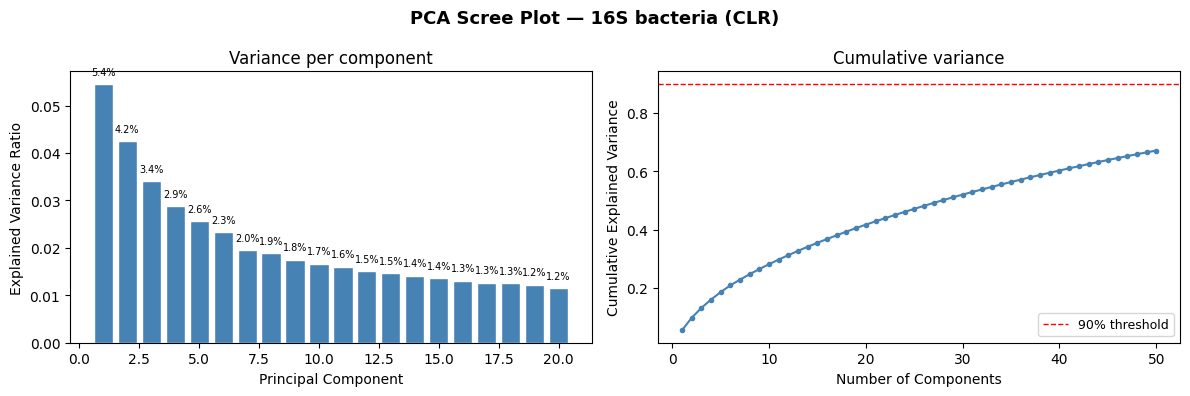

In [10]:
# Scree plot
n_show = 20
cumul  = np.cumsum(ev_16s)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('PCA Scree Plot — 16S bacteria (CLR)', fontsize=13, fontweight='bold')

ax1.bar(range(1, n_show + 1), ev_16s[:n_show], color='steelblue', edgecolor='white')
for i, v in enumerate(ev_16s[:n_show]):
    ax1.text(i + 1, v + 0.002, f'{v:.1%}', ha='center', fontsize=7)
ax1.set_xlabel('Principal Component')
ax1.set_ylabel('Explained Variance Ratio')
ax1.set_title('Variance per component')

n90 = int(np.argmax(cumul >= 0.9)) + 1
ax2.plot(range(1, len(ev_16s) + 1), cumul, marker='o', markersize=3, lw=1.5, color='steelblue')
ax2.axhline(0.9, color='red', ls='--', lw=1, label='90% threshold')
ax2.set_xlabel('Number of Components')
ax2.set_ylabel('Cumulative Explained Variance')
ax2.set_title('Cumulative variance')
ax2.legend(fontsize=9)

plt.tight_layout()
fig.savefig(FIG_DIR / '16s_pca_scree.pdf', bbox_inches='tight')
plt.show()

In [ ]:
# PCA coloured by categorical metadata
cat_vars = [
    'sample_type',
    'management_type',
    'farm_id',
    'farmer',
    'collection_batch',
    'extraction_batch',
    'pcr_batch_16s',
    'qubit_batch_16s',
    'is_pollination_dic',
    'is_pollination_clsm',
    'is_germination',
    'is_hyphae_present',
    'fungal_colonization_score',
    'is_spore_present',
    'is_insect_present',
]

fig = plot_pca_panel(
    pcs_16s, ev_16s, meta_16s,
    color_vars=cat_vars,
    palettes=PALETTES,
    title_prefix=f'PCA - 16S bacteria - counts - filter (prev>={PREV_THRESHOLD:.0%}, min_total>={MIN_TOTAL}) - TSS - multi-replace - CLR',
    n_cols=3, ellipses=True
)
fig.savefig(FIG_DIR / '16s_pca_categorical.pdf', bbox_inches='tight')
plt.show()


SyntaxError: invalid character '²' (U+00B2) (2533734518.py, line 24)

In [ ]:
# PCA coloured by continuous microscopy variables
fig = plot_pca_continuous(
    pcs_16s, ev_16s, meta_16s,
    cont_vars=['pi_dic', 'pi_clsm', 'callose_plug_index'],
    cmaps=CMAPS,
    title_prefix='16S bacteria'
)
fig.savefig(FIG_DIR / '16s_pca_continuous.pdf', bbox_inches='tight')
plt.show()

In [ ]:
# Load taxonomy tables and build ASV -> short label maps
def parse_taxon(taxon_str: str, n_levels: int = 2) -> str:
    """Return the deepest n non-empty taxonomy levels as a readable label."""
    parts = [p.strip() for p in taxon_str.split(';')]
    labeled = []
    for p in parts:
        if '__' in p:
            prefix, val = p.split('__', 1)
            val = val.strip()
            if prefix.lower() == 'sh':   # skip UNITE SH codes
                continue
            if val and val not in ('NA', 'unidentified', 'uncultured', ''):
                labeled.append(val)
    if not labeled:
        return taxon_str[:30]
    return ' '.join(labeled[-n_levels:]).replace('_', ' ')

tax_16s = (
    pd.read_csv(BIOM_DIR / 'cfm_16s_bacteria_biosamples_taxonomy.tsv',
                sep='\t', index_col=0)
    .assign(label=lambda df: df['Taxon'].apply(lambda x: parse_taxon(str(x))))
    ['label']
)
tax_its1 = (
    pd.read_csv(BIOM_DIR / 'cfm_its1_fungi_biosamples_taxonomy.tsv',
                sep='\t', index_col=0)
    .assign(label=lambda df: df['Taxon'].apply(lambda x: parse_taxon(str(x))))
    ['label']
)
print(f'16S  taxonomy: {len(tax_16s)} ASVs  | example: {tax_16s.iloc[0]}')
print(f'ITS1 taxonomy: {len(tax_its1)} ASVs | example: {tax_its1.iloc[0]}')


In [ ]:
# PC loadings — top 20 ASVs with taxonomy labels
n_top   = 20
asv_ids = clr_16s.columns.tolist()

fig, axes = plt.subplots(1, 2, figsize=(14, 7))
fig.suptitle('PCA Loadings — 16S bacteria', fontsize=13, fontweight='bold')

for ax, pc_idx in zip(axes, [0, 1]):
    loadings = pca_16s.components_[pc_idx]
    top_idx  = np.argsort(np.abs(loadings))[-n_top:]
    vals     = loadings[top_idx]
    names    = [
        tax_16s.get(asv_ids[i], asv_ids[i][:12]) + f' [{asv_ids[i][:6]}]'
        for i in top_idx
    ]
    colors   = ['steelblue' if v >= 0 else 'tomato' for v in vals]
    ax.barh(names, vals, color=colors)
    ax.axvline(0, color='black', lw=0.8)
    ax.set_xlabel('Loading value')
    ax.set_title(
        f'PC{pc_idx + 1}  ({ev_16s[pc_idx]:.1%} variance)\n'
        'blue = positive, red = negative'
    )
    ax.tick_params(axis='y', labelsize=7)

plt.tight_layout()
fig.savefig(FIG_DIR / '16s_pca_loadings.pdf', bbox_inches='tight')
plt.show()


### PCA pairplot — first 5 components (16S)


In [ ]:
# Project onto first 5 PCs
n_pcs = 5
pcs_5_16s = pcs_16s[:, :n_pcs]
pc_cols   = [f'PC{i+1}' for i in range(n_pcs)]
pcs_df_16s = pd.DataFrame(pcs_5_16s, index=ids_16s, columns=pc_cols)

pairplot_vars_16s = [
    ('sample_type',             PALETTES['sample_type']),
    ('management_type',         PALETTES['management_type']),
    ('farm_id',                 PALETTES['farm_id']),
    ('is_pollination_clsm',     PALETTES['is_pollination_clsm']),
    ('is_germination',          PALETTES['is_germination']),
    ('fungal_colonization_score', PALETTES['fungal_colonization_score']),
    ('farmer',            PALETTES['farmer']),
    ('collection_batch',  PALETTES['collection_batch']),
    ('qubit_batch_16s',   PALETTES['qubit_batch_16s']),
]

for col, palette in pairplot_vars_16s:
    df_plot = pcs_df_16s.copy()
    df_plot[col] = meta_16s[col].values
    df_plot = df_plot.dropna(subset=[col])
    df_plot[col] = df_plot[col].apply(safe_to_str)

    # Build palette and hue_order with NA excluded, preserving palette key order
    pal_str   = {safe_to_str(k): v for k, v in palette.items() if not pd.isna(k)}
    hue_order = [k for k in pal_str if k in df_plot[col].values]

    g = sns.pairplot(
        df_plot, hue=col,
        hue_order=hue_order,
        palette=pal_str,
        plot_kws={"alpha": 0.5, "s": 40, "linewidths": 0},
        diag_kind="hist", diag_kws={"alpha": 0.5, "bins": 15},
    )
    g.figure.suptitle(
        f'PCA pairplot (first {n_pcs} PCs) - 16S bacteria, coloured by: {col}',
        y=1.02, fontsize=12
    )
    g.figure.savefig(FIG_DIR / f'16s_pca_pairplot_{col}.pdf', bbox_inches='tight')
    plt.show()


## 8. PCA — ITS1 fungi

In [ ]:
ids_its1  = clr_its1.index.tolist()
meta_its1 = meta.reindex(ids_its1)

pca_its1  = PCA(n_components=min(len(ids_its1) - 1, 50), random_state=RANDOM_STATE)
pcs_its1  = pca_its1.fit_transform(clr_its1.values)
ev_its1   = pca_its1.explained_variance_ratio_

print(f'PC1={ev_its1[0]:.1%}  PC2={ev_its1[1]:.1%}  PC3={ev_its1[2]:.1%}')

In [ ]:
cumul_its1 = np.cumsum(ev_its1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('PCA Scree Plot — ITS1 fungi (CLR)', fontsize=13, fontweight='bold')

ax1.bar(range(1, n_show + 1), ev_its1[:n_show], color='#DD8452', edgecolor='white')
for i, v in enumerate(ev_its1[:n_show]):
    ax1.text(i + 1, v + 0.002, f'{v:.1%}', ha='center', fontsize=7)
ax1.set_xlabel('Principal Component')
ax1.set_ylabel('Explained Variance Ratio')
ax1.set_title('Variance per component')

n90_its1 = int(np.argmax(cumul_its1 >= 0.9)) + 1
ax2.plot(range(1, len(ev_its1) + 1), cumul_its1, marker='o', markersize=3, lw=1.5, color='#DD8452')
ax2.axhline(0.9, color='red', ls='--', lw=1, label='90% threshold')
ax2.set_xlabel('Number of Components')
ax2.set_ylabel('Cumulative Explained Variance')
ax2.set_title('Cumulative variance')
ax2.legend(fontsize=9)

plt.tight_layout()
fig.savefig(FIG_DIR / 'its1_pca_scree.pdf', bbox_inches='tight')
plt.show()

In [ ]:
cat_vars_its1 = [
    'sample_type',
    'management_type',
    'farm_id',
    'farmer',
    'collection_batch',
    'extraction_batch',
    'pcr_batch_its1',
    'qubit_batch_its1',
    'is_pollination_dic',
    'is_pollination_clsm',
    'is_germination',
    'is_hyphae_present',
    'is_spore_present',
    'fungal_colonization_score',
    'is_insect_present',
]

fig = plot_pca_panel(
    pcs_its1, ev_its1, meta_its1,
    color_vars=cat_vars_its1,
    palettes=PALETTES,
    title_prefix=f'PCA - ITS1 fungi - counts - filter (prev>={PREV_THRESHOLD:.0%}, min_total>={MIN_TOTAL}) - TSS - multi-replace - CLR',
    n_cols=3, ellipses=True
)
fig.savefig(FIG_DIR / 'its1_pca_categorical.pdf', bbox_inches='tight')
plt.show()


In [ ]:
fig = plot_pca_continuous(
    pcs_its1, ev_its1, meta_its1,
    cont_vars=['pi_dic', 'pi_clsm', 'callose_plug_index'],
    cmaps=CMAPS,
    title_prefix='ITS1 fungi'
)
fig.savefig(FIG_DIR / 'its1_pca_continuous.pdf', bbox_inches='tight')
plt.show()

In [ ]:
asv_ids_its1 = clr_its1.columns.tolist()

fig, axes = plt.subplots(1, 2, figsize=(14, 7))
fig.suptitle('PCA Loadings — ITS1 fungi', fontsize=13, fontweight='bold')

for ax, pc_idx in zip(axes, [0, 1]):
    loadings = pca_its1.components_[pc_idx]
    top_idx  = np.argsort(np.abs(loadings))[-n_top:]
    vals     = loadings[top_idx]
    names    = [
        tax_its1.get(asv_ids_its1[i], asv_ids_its1[i][:12]) + f' [{asv_ids_its1[i][:6]}]'
        for i in top_idx
    ]
    colors   = ['#DD8452' if v >= 0 else 'slateblue' for v in vals]
    ax.barh(names, vals, color=colors)
    ax.axvline(0, color='black', lw=0.8)
    ax.set_xlabel('Loading value')
    ax.set_title(
        f'PC{pc_idx + 1}  ({ev_its1[pc_idx]:.1%} variance)\n'
        'orange = positive, purple = negative'
    )
    ax.tick_params(axis='y', labelsize=7)

plt.tight_layout()
fig.savefig(FIG_DIR / 'its1_pca_loadings.pdf', bbox_inches='tight')
plt.show()


### PCA pairplot — first 5 components (ITS1)

In [ ]:
pcs_df_its1 = pd.DataFrame(pcs_its1[:, :n_pcs], index=ids_its1, columns=pc_cols)

pairplot_vars_its1 = [
    ('sample_type',               PALETTES['sample_type']),
    ('management_type',           PALETTES['management_type']),
    ('is_pollination_clsm',       PALETTES['is_pollination_clsm']),
    ('is_germination',            PALETTES['is_germination']),
    ('farm_id',                   PALETTES['farm_id']),
    ('fungal_colonization_score',  PALETTES['fungal_colonization_score']),
    ('farmer',             PALETTES['farmer']),
    ('collection_batch',   PALETTES['collection_batch']),
    ('qubit_batch_its1',   PALETTES['qubit_batch_its1']),
]

for col, palette in pairplot_vars_its1:
    df_plot = pcs_df_its1.copy()
    df_plot[col] = meta_its1[col].values
    df_plot = df_plot.dropna(subset=[col])
    df_plot[col] = df_plot[col].apply(safe_to_str)

    # Build palette and hue_order with NA excluded, preserving palette key order
    pal_str   = {safe_to_str(k): v for k, v in palette.items() if not pd.isna(k)}
    hue_order = [k for k in pal_str if k in df_plot[col].values]

    g = sns.pairplot(
        df_plot, hue=col,
        hue_order=hue_order,
        palette=pal_str,
        plot_kws={"alpha": 0.5, "s": 40, "linewidths": 0},
        diag_kind="hist", diag_kws={"alpha": 0.5, "bins": 15},
    )
    g.figure.suptitle(
        f'PCA pairplot (first {n_pcs} PCs) - ITS1 fungi, coloured by: {col}',
        y=1.02, fontsize=12
    )
    g.figure.savefig(FIG_DIR / f'its1_pca_pairplot_{col}.pdf', bbox_inches='tight')
    plt.show()


## 9. t-SNE helper functions

In [ ]:
def plot_ordination_panel(
    coords, meta_aligned, color_vars, palettes,
    title_prefix='', n_cols=3, figsize_per=5, hulls=True,
    axis_label=('Dim 1', 'Dim 2')
):
    """
    Generic ordination scatter panel coloured by metadata variables.
    Works for t-SNE, UMAP, PCoA — any 2D embedding.

    hulls : draw convex hull per group.
        Convex hull = minimum convex polygon enclosing all points of a group
        (scipy.spatial.ConvexHull, O(n log n) QuickHull algorithm).
        Appropriate for t-SNE and UMAP because both methods tend to cluster
        similar samples spatially. Note: this is NOT a confidence region —
        it simply shows the extent of each group in the 2D projection.
    """
    n_plots = len(color_vars)
    n_rows  = (n_plots + n_cols - 1) // n_cols
    fig, axes = plt.subplots(
        n_rows, n_cols,
        figsize=(figsize_per * n_cols, figsize_per * n_rows)
    )
    axes = np.array(axes).flatten()
    fig.suptitle(title_prefix, fontsize=14, fontweight='bold', y=1.01)

    for ax_idx, col in enumerate(color_vars):
        ax      = axes[ax_idx]
        palette = palettes.get(col, {})
        series  = meta_aligned[col] if col in meta_aligned.columns else pd.Series(
            [pd.NA] * len(coords), name=col
        )

        if not palette:
            uniq    = list(series.dropna().unique())
            palette = dict(zip(uniq, sns.color_palette('tab10', n_colors=len(uniq))))

        for val, color in palette.items():
            mask = series.isna().to_numpy(dtype=bool) if pd.isna(val) else (series == val).to_numpy(dtype=bool, na_value=False)
            if not mask.any():
                continue
            pts = coords[mask]
            ax.scatter(
                pts[:, 0], pts[:, 1],
                c=[color], label=str(val),
                alpha=0.6, s=50, linewidths=0.4, edgecolors='black'
            )
            if hulls and not pd.isna(val) and mask.sum() >= 3:
                draw_convex_hull(pts, ax, color)

        ax.set_xlabel(axis_label[0], fontsize=9)
        ax.set_ylabel(axis_label[1], fontsize=9)
        ax.set_title(col, fontsize=10)
        ax.legend(fontsize=8, markerscale=1.5, framealpha=0.6, loc='best')

    for ax in axes[n_plots:]:
        ax.set_visible(False)

    plt.tight_layout()
    return fig


# Keep old name as alias so existing t-SNE calls don't break
plot_tsne_panel = plot_ordination_panel

print('Ordination panel helper defined.')


## 10. t-SNE — 16S bacteria

**Perplexity** is the key hyperparameter of t-SNE.
Small values (~5) capture local structure; large values capture global layout.
We run t-SNE for several perplexity values and compare.

In [ ]:
perplexities = [5, 10, 15, 20, 30, 100]

print('Computing t-SNE (16S) for each perplexity...')
tsne_16s = {}
for perp in perplexities:
    print(f'  perplexity={perp}...', end=' ', flush=True)
    tsne_16s[perp] = TSNE(
        n_components=2, perplexity=perp,
        max_iter=2000, random_state=RANDOM_STATE
    ).fit_transform(clr_16s.values)
    print('done')

In [ ]:
# Comparison panel: rows = colouring variable, columns = perplexity
row_configs = [
    ('sample_type',   PALETTES['sample_type']),
    ('is_germination', PALETTES['is_germination']),
    ('farm_id',       PALETTES['farm_id']),
    ('management_type', PALETTES['management_type']),
]

fig, axes = plt.subplots(
    len(row_configs), len(perplexities),
    figsize=(4.5 * len(perplexities), 4.5 * len(row_configs))
)
fig.suptitle('t-SNE perplexity comparison — 16S bacteria (CLR)',
             fontsize=13, fontweight='bold', y=1.01)

for row_idx, (col, palette) in enumerate(row_configs):
    series = meta_16s[col] if col in meta_16s.columns else pd.Series([pd.NA] * len(ids_16s))
    for col_idx, perp in enumerate(perplexities):
        ax     = axes[row_idx, col_idx]
        coords = tsne_16s[perp]
        for val, color in palette.items():
            mask = series.isna().to_numpy(dtype=bool) if pd.isna(val) else (series == val).to_numpy(dtype=bool, na_value=False)
            if mask.any():
                ax.scatter(coords[mask, 0], coords[mask, 1],
                           c=[color], label=str(val), alpha=0.6, s=45, linewidths=0.4, edgecolors="black")
        if row_idx == 0:
            ax.set_title(f'perplexity={perp}', fontsize=10)
        ax.set_xlabel('t-SNE 1', fontsize=8)
        ax.set_ylabel('t-SNE 2', fontsize=8)
        ax.tick_params(labelsize=7)

    axes[row_idx, 0].annotate(
        col, xy=(-0.25, 0.5), xycoords='axes fraction',
        fontsize=10, fontweight='bold', ha='center', va='center',
        rotation=90, annotation_clip=False
    )
    axes[row_idx, -1].legend(fontsize=7, markerscale=1.8, framealpha=0.6,
                             bbox_to_anchor=(1.02, 1), loc='upper left')

plt.subplots_adjust(left=0.1, hspace=0.35, wspace=0.3)
fig.savefig(FIG_DIR / '16s_tsne_perplexity_comparison.pdf', bbox_inches='tight')
plt.show()

In [ ]:
# Best t-SNE — full panel with convex hulls
# Adjust best_perp_16s after inspecting the comparison above
best_perp_16s = 15
coords_16s    = tsne_16s[best_perp_16s]

fig = plot_tsne_panel(
    coords_16s, meta_16s,
    color_vars=cat_vars,
    palettes=PALETTES,
    title_prefix=(
        f'16S bacteria · t-SNE (perplexity={best_perp_16s}) + convex hulls\n'
        f'transformation: counts - filter (prev>={PREV_THRESHOLD:.0%}, min_total>={MIN_TOTAL}) - TSS - multi-replace - CLR'
    ),
    n_cols=3, hulls=True,
    axis_label=('t-SNE 1', 't-SNE 2')
)
fig.savefig(FIG_DIR / '16s_tsne_best.pdf', bbox_inches='tight')
plt.show()


## 11. t-SNE — ITS1 fungi

In [ ]:
print('Computing t-SNE (ITS1) for each perplexity...')
tsne_its1 = {}
for perp in perplexities:
    print(f'  perplexity={perp}...', end=' ', flush=True)
    tsne_its1[perp] = TSNE(
        n_components=2, perplexity=perp,
        max_iter=2000, random_state=RANDOM_STATE
    ).fit_transform(clr_its1.values)
    print('done')

In [ ]:
row_configs_its1 = [
    ('sample_type', PALETTES['sample_type']),
    ('management_type', PALETTES['management_type']),
    ('farm_id', PALETTES['farm_id']),
    ('is_pollination_clsm', PALETTES['is_pollination_clsm']),
    ('is_germination', PALETTES['is_germination']),
    ('fungal_colonization_score', PALETTES['fungal_colonization_score']),
]

fig, axes = plt.subplots(
    len(row_configs_its1), len(perplexities),
    figsize=(4.5 * len(perplexities), 4.5 * len(row_configs_its1))
)
fig.suptitle('t-SNE perplexity comparison — ITS1 fungi (CLR)',
             fontsize=13, fontweight='bold', y=1.01)

for row_idx, (col, palette) in enumerate(row_configs_its1):
    series = meta_its1[col] if col in meta_its1.columns else pd.Series([pd.NA] * len(ids_its1))
    for col_idx, perp in enumerate(perplexities):
        ax     = axes[row_idx, col_idx]
        coords = tsne_its1[perp]
        for val, color in palette.items():
            mask = series.isna().to_numpy(dtype=bool) if pd.isna(val) else (series == val).to_numpy(dtype=bool, na_value=False)
            if mask.any():
                ax.scatter(coords[mask, 0], coords[mask, 1],
                           c=[color], label=str(val), alpha=0.6, s=45, linewidths=0.4, edgecolors="black")
        if row_idx == 0:
            ax.set_title(f'perplexity={perp}', fontsize=10)
        ax.set_xlabel('t-SNE 1', fontsize=8)
        ax.set_ylabel('t-SNE 2', fontsize=8)
        ax.tick_params(labelsize=7)

    axes[row_idx, 0].annotate(
        col, xy=(-0.25, 0.5), xycoords='axes fraction',
        fontsize=10, fontweight='bold', ha='center', va='center',
        rotation=90, annotation_clip=False
    )
    axes[row_idx, -1].legend(fontsize=7, markerscale=1.8, framealpha=0.6,
                             bbox_to_anchor=(1.02, 1), loc='upper left')

plt.subplots_adjust(left=0.1, hspace=0.35, wspace=0.3)
fig.savefig(FIG_DIR / 'its1_tsne_perplexity_comparison.pdf', bbox_inches='tight')
plt.show()

In [ ]:
# Adjust best_perp_its1 after inspecting the comparison above
best_perp_its1 = 15
coords_its1    = tsne_its1[best_perp_its1]

fig = plot_tsne_panel(
    coords_its1, meta_its1,
    color_vars=cat_vars_its1,
    palettes=PALETTES,
    title_prefix=(
        f'ITS1 fungi · t-SNE (perplexity={best_perp_its1}) + convex hulls\n'
        f'transformation: counts - filter (prev>={PREV_THRESHOLD:.0%}, min_total>={MIN_TOTAL}) - TSS - multi-replace - CLR'
    ),
    n_cols=3, hulls=True,
    axis_label=('t-SNE 1', 't-SNE 2')
)
fig.savefig(FIG_DIR / 'its1_tsne_best.pdf', bbox_inches='tight')
plt.show()


In [ ]:
# perplexity=100 gives a more global structure
best_perp_its1 = 100
coords_its1    = tsne_its1[best_perp_its1]

fig = plot_tsne_panel(
    coords_its1, meta_its1,
    color_vars=cat_vars_its1,
    palettes=PALETTES,
    title_prefix=(
        f'ITS1 fungi · t-SNE (perplexity={best_perp_its1}) + convex hulls\n'
        f'transformation: counts - filter (prev>={PREV_THRESHOLD:.0%}, min_total>={MIN_TOTAL}) - TSS - multi-replace - CLR'
    ),
    n_cols=3, hulls=True,
    axis_label=('t-SNE 1', 't-SNE 2')
)
fig.savefig(FIG_DIR / 'its1_tsne_best.pdf', bbox_inches='tight')
plt.show()


In [ ]:
# Management type and farm id are confounded by extraction and pcr batches:
meta.groupby(['farm_id', 'extraction_batch']).size().unstack(fill_value=0)


In [ ]:
meta.groupby(['farm_id', 'pcr_batch_its1']).size().unstack(fill_value=0)


## 12. UMAP

UMAP preserves both local **and** global structure better than t-SNE.
Key hyperparameter: **n_neighbors** (analogous to perplexity).

Same colour panels as t-SNE.

### 11.1 UMAP — 16S bacteria

In [ ]:
n_neighbors_list = [5, 15, 30, 50]

print('Computing UMAP (16S)...')
umap_16s = {}
for nn in n_neighbors_list:
    print(f'  n_neighbors={nn}...', end=' ', flush=True)
    umap_16s[nn] = UMAP(
        n_components=2, n_neighbors=nn, min_dist=0.1,
        random_state=RANDOM_STATE
    ).fit_transform(clr_16s.values)
    print('done')


In [ ]:
# n_neighbors comparison panel (same style as t-SNE perplexity comparison)
row_configs_umap = [
    ('sample_type',    PALETTES['sample_type']),
    ('management_type', PALETTES['management_type']),
    ('farm_id',        PALETTES['farm_id']),
    ('is_germination', PALETTES['is_germination']),
]

fig, axes = plt.subplots(
    len(row_configs_umap), len(n_neighbors_list),
    figsize=(4.5 * len(n_neighbors_list), 4.5 * len(row_configs_umap))
)
fig.suptitle('UMAP n_neighbors comparison — 16S bacteria (CLR)',
             fontsize=13, fontweight='bold', y=1.01)

for row_idx, (col, palette) in enumerate(row_configs_umap):
    series = meta_16s[col] if col in meta_16s.columns else pd.Series([pd.NA] * len(ids_16s))
    for col_idx, nn in enumerate(n_neighbors_list):
        ax     = axes[row_idx, col_idx]
        coords = umap_16s[nn]
        for val, color in palette.items():
            mask = series.isna().to_numpy(dtype=bool) if pd.isna(val) else (series == val).to_numpy(dtype=bool, na_value=False)
            if mask.any():
                ax.scatter(coords[mask, 0], coords[mask, 1],
                           c=[color], label=str(val), alpha=0.6, s=45,
                           linewidths=0.4, edgecolors='black')
        if row_idx == 0:
            ax.set_title('n_neighbors=' + str(nn), fontsize=10)
        ax.set_xlabel('UMAP 1', fontsize=8)
        ax.set_ylabel('UMAP 2', fontsize=8)
        ax.tick_params(labelsize=7)

    axes[row_idx, 0].annotate(
        col, xy=(-0.25, 0.5), xycoords='axes fraction',
        fontsize=10, fontweight='bold', ha='center', va='center',
        rotation=90, annotation_clip=False
    )
    axes[row_idx, -1].legend(fontsize=7, markerscale=1.8, framealpha=0.6,
                             bbox_to_anchor=(1.02, 1), loc='upper left')

plt.subplots_adjust(left=0.1, hspace=0.35, wspace=0.3)
fig.savefig(FIG_DIR / '16s_umap_nn_comparison.pdf', bbox_inches='tight')
plt.show()


In [ ]:
# Best UMAP 16S — full panel with convex hulls
# Adjust best_nn_16s after inspecting the n_neighbors comparison above
best_nn_16s     = 30
coords_umap_16s = umap_16s[best_nn_16s]

fig = plot_ordination_panel(
    coords_umap_16s, meta_16s,
    color_vars=cat_vars,
    palettes=PALETTES,
    title_prefix=(
        f'UMAP — 16S bacteria (n_neighbors={best_nn_16s}) + convex hulls\n'
        f'transformation: counts - filter (prev>={PREV_THRESHOLD:.0%}, min_total>={MIN_TOTAL}) - TSS - multi-replace - CLR'
    ),
    n_cols=3, hulls=True,
    axis_label=('UMAP 1', 'UMAP 2')
)
fig.savefig(FIG_DIR / '16s_umap_best.pdf', bbox_inches='tight')
plt.show()


### 11.2 UMAP — ITS1 fungi

In [ ]:
print('Computing UMAP (ITS1)...')
umap_its1 = {}
for nn in n_neighbors_list:
    print(f'  n_neighbors={nn}...', end=' ', flush=True)
    umap_its1[nn] = UMAP(
        n_components=2, n_neighbors=nn, min_dist=0.1,
        random_state=RANDOM_STATE
    ).fit_transform(clr_its1.values)
    print('done')


In [ ]:
row_configs_umap_its1 = [
    ('sample_type',              PALETTES['sample_type']),
    ('management_type',          PALETTES['management_type']),
    ('farm_id',                  PALETTES['farm_id']),
    ('fungal_colonization_score', PALETTES['fungal_colonization_score']),
]

fig, axes = plt.subplots(
    len(row_configs_umap_its1), len(n_neighbors_list),
    figsize=(4.5 * len(n_neighbors_list), 4.5 * len(row_configs_umap_its1))
)
fig.suptitle('UMAP n_neighbors comparison — ITS1 fungi (CLR)',
             fontsize=13, fontweight='bold', y=1.01)

for row_idx, (col, palette) in enumerate(row_configs_umap_its1):
    series = meta_its1[col] if col in meta_its1.columns else pd.Series([pd.NA] * len(ids_its1))
    for col_idx, nn in enumerate(n_neighbors_list):
        ax     = axes[row_idx, col_idx]
        coords = umap_its1[nn]
        for val, color in palette.items():
            mask = series.isna().to_numpy(dtype=bool) if pd.isna(val) else (series == val).to_numpy(dtype=bool, na_value=False)
            if mask.any():
                ax.scatter(coords[mask, 0], coords[mask, 1],
                           c=[color], label=str(val), alpha=0.6, s=45,
                           linewidths=0.4, edgecolors='black')
        if row_idx == 0:
            ax.set_title('n_neighbors=' + str(nn), fontsize=10)
        ax.set_xlabel('UMAP 1', fontsize=8)
        ax.set_ylabel('UMAP 2', fontsize=8)
        ax.tick_params(labelsize=7)

    axes[row_idx, 0].annotate(
        col, xy=(-0.25, 0.5), xycoords='axes fraction',
        fontsize=10, fontweight='bold', ha='center', va='center',
        rotation=90, annotation_clip=False
    )
    axes[row_idx, -1].legend(fontsize=7, markerscale=1.8, framealpha=0.6,
                             bbox_to_anchor=(1.02, 1), loc='upper left')

plt.subplots_adjust(left=0.1, hspace=0.35, wspace=0.3)
fig.savefig(FIG_DIR / 'its1_umap_nn_comparison.pdf', bbox_inches='tight')
plt.show()


In [ ]:
# Best UMAP ITS1 — full panel with convex hulls
# Adjust best_nn_its1 after inspecting the n_neighbors comparison above
best_nn_its1     = 30
coords_umap_its1 = umap_its1[best_nn_its1]

fig = plot_ordination_panel(
    coords_umap_its1, meta_its1,
    color_vars=cat_vars_its1,
    palettes=PALETTES,
    title_prefix=(
        f'UMAP — ITS1 fungi (n_neighbors={best_nn_its1}) + convex hulls\n'
        f'transformation: counts - filter (prev>={PREV_THRESHOLD:.0%}, min_total>={MIN_TOTAL}) - TSS - multi-replace - CLR'
    ),
    n_cols=3, hulls=True,
    axis_label=('UMAP 1', 'UMAP 2')
)
fig.savefig(FIG_DIR / 'its1_umap_best.pdf', bbox_inches='tight')
plt.show()
